In [31]:
#%pip install pandas numpy matplotlib

**LIBRARIES**

In [65]:
import pandas as pd
import numpy as np
import os 
import matplotlib.pyplot as plt
import viridis
from matplotlib.colors import LogNorm

ModuleNotFoundError: No module named 'viridis'

# PLOTS

### Sampling

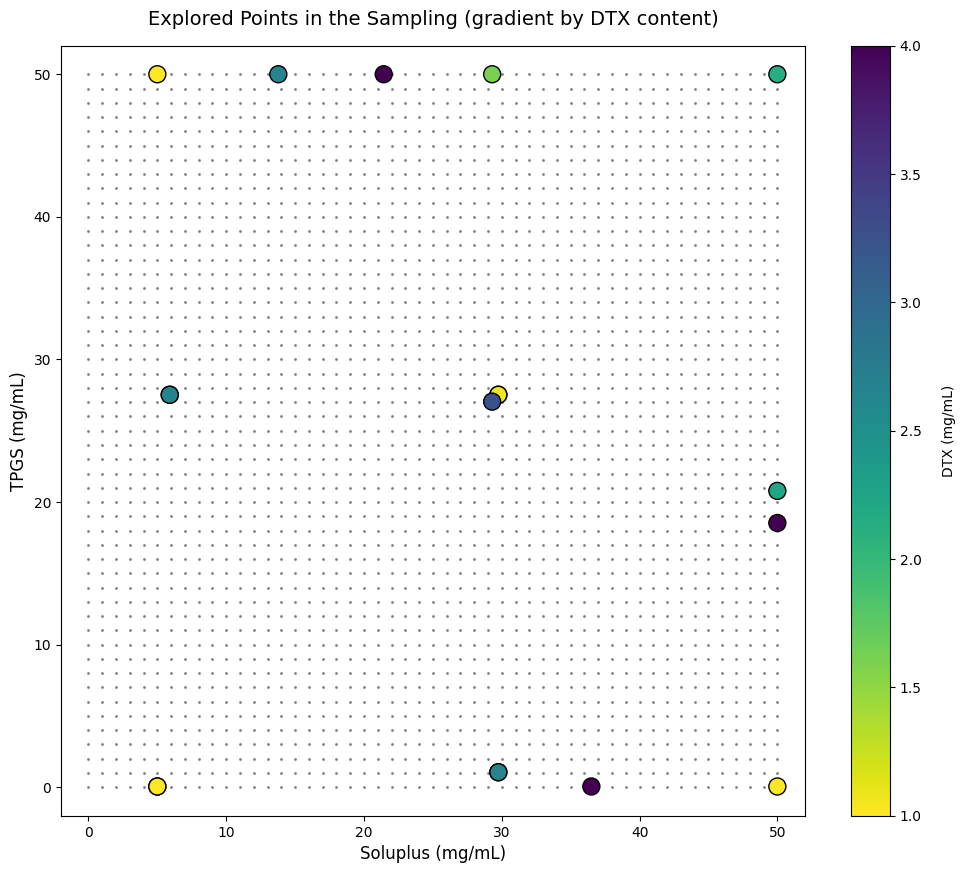

In [78]:
BASE_DIR = os.getcwd()
file_name = "Design_Expert-sampling.csv" 
file_path = os.path.join(BASE_DIR, file_name)

def explored_sampling(filepath):
    df = pd.read_csv(filepath, sep=None, engine='python')
    df.columns = df.columns.str.strip()

    val_x = df.iloc[:, 1] # Soluplus values
    val_y = df.iloc[:, 2] # TPGS values
    val_z = df.iloc[:, 3] # DTX values 

    ##---- PLOT ----##
    plt.figure(figsize=(12, 10))
    
    # Fondo del gráfico con rejilla
    x_grid = np.arange(0, 51, 1.0) 
    y_grid = np.arange(0, 51, 1.0)
    grid_x, grid_y = np.meshgrid(x_grid, y_grid)
    plt.scatter(grid_x, grid_y, color='grey', s=1, zorder=1)

    # Dibujar puntos explorados 
    scatter = plt.scatter(val_x, val_y, 
                c=val_z,
                cmap = 'viridis_r', # se pone _r para que el degradado vaya de color claro (menos DTX) a oscuro (más DTX)
                marker='o', 
                edgecolors='black', 
                s=150, 
                zorder=5, 
                label='Design Expert Points')
    
    # Barra de colores para DTX

    cbar = plt.colorbar(scatter)
    cbar.set_label('DTX (mg/mL)', labelpad=15)

    # Estética
    plt.title("Explored Points in the Sampling (gradient by DTX content)", fontsize=14, pad=15)
    plt.xlabel("Soluplus (mg/mL)", fontsize=12)
    plt.ylabel("TPGS (mg/mL)", fontsize=12)

    plt.xlim(-2, 52)
    plt.ylim(-2, 52)
    plt.xticks(np.arange(0, 51, 10))
    plt.yticks(np.arange(0, 51, 10))
    
    plt.show()

# IMPORTANTE: No olvides llamar a la función
if os.path.exists(file_path):
    explored_sampling(file_path)
else:
    print(f"Error: No se encuentra el archivo en {file_path}")

### Rounds: proposed points

In [9]:
class DEPlot: 
    def __init__(self):
        self.name = "Puntos explorados"
        self.limits = [(0, 55), (0, 55)] # Ajustamos de 0 a 55 para cubrir todo el rango y dejar margen
    
    def lectura(self, filepath: str):
        # 1. Cargar datos 
        # Leemos el archivo detectando automáticamente el separador (puede ser coma, punto y coma, tabulación, etc.)
        df = pd.read_csv(filepath, sep=None, engine='python')

        # Limpiamos nombres de columnas (quita espacios invisibles como " X" -> "X")
        df.columns = df.columns.str.strip()
        print(f"Columnas detectadas: {list(df.columns)}")

        # 3. Extraer valores de la columna 2 (X) y de la columna 3(Y) (Usando .iloc es más seguro si las columnas son la 2 y la 3)
        val_x = df.iloc[:, 1] # iloc[:, 1] es la segunda columna donde estan los valores de Soluplus 
        val_y = df.iloc[:, 2] # iloc[:, 2] es la tercera columna donde estan los valores de TPGS 

        return val_x, val_y, df

In [8]:
def plot_DE(val_x, val_y, round: str): #, save_figure: bool = False): 

    
    ###-PLOT-###
    # 1. Crear el fondo de la función
    x_range = np.linspace(0, 55, 400)
    y_range = np.linspace(0, 55, 400)
    X_mesh, Y_mesh = np.meshgrid(x_range, y_range)

    # 2. Dibujar el mapa
    plt.figure(figsize=(10, 7))
    plt.contourf(X_mesh, Y_mesh, Z_mesh, levels=np.linspace(np.nanmin(val_z), np.nanmax(val_z), 35), norm=LogNorm(), cmap='viridis', alpha=0.7)
    plt.colorbar(label='Himmelblau value')

    # 3. Dibujar TUS puntos (usando el df que ya tienes en memoria)
    plt.scatter(val_x, val_y, color='red', edgecolors='white', s=80, label='Explored points')

    # Añadir etiquetas de número de RUN
    #for i, row in df.iterrows():
    #    plt.text(row.iloc[1]+0.1, row.iloc[2]+0.1, str(int(row.iloc[0])), color='white', fontsize=9)

    plt.title(f"Round {round}")
    plt.xlabel("Soluplus (mg/mL)")
    plt.ylabel("TPGS (mg/mL)")
    plt.legend()

    return plt

In [33]:
#Rutes
filepath = "emma-reig/TFM_MuBiB_Emma-Reig/Design_Expert-sampling.csv"
file_name = "Design_Expert-sampling.csv" 
save_plot = True

def explored_sampling(filepath):
    df = pd.read_csv(filepath, sep=None, engine='python')
    df.columns = df.columns.str.strip()

    val_x = df.iloc[:, 1] # Soluplus values
    val_y = df.iloc[:, 2] # TPGS values
    

    ##----PLOT----##
    plt.figure(figsize=(10, 7))
    
    if explored_points:
        # Creamos el fondo interpolado
        xi = np.linspace(0, 55, 500)
        yi = np.linspace(0, 55, 500)
        X_mesh, Y_mesh = np.meshgrid(xi, yi)
        
        # 'linear' es más seguro para pocos puntos; 'cubic' es más estético
        Z_mesh = griddata((val_x, val_y), val_z, (X_mesh, Y_mesh), method='linear')
        
        cp = plt.contourf(X_mesh, Y_mesh, Z_mesh, levels=20, cmap='viridis', alpha=0.8)
        plt.colorbar(cp, label='Respuesta (Columna 4)')
        plt.title("Mapa de Calor: Resultados Experimentales")
    else:
        # Si no hay datos en la Columna 4, solo configuramos el área de dibujo
        plt.xlim(0, 55)
        plt.ylim(0, 55)
        plt.title("Explored Points in the Sampling")

    # 4. Dibujar los puntos (siempre se dibujan)
    plt.scatter(val_x, val_y, color='red', edgecolors='white', s=100, zorder=5, label='Muestras')

    # 5. Estética final
    plt.xlabel("Soluplus (mg/mL)")
    plt.ylabel("TPGS (mg/mL)")
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.legend()

    if save_plot:
        nombre_salida = "grafico_muestreo.jpg"
        plt.savefig(nombre_salida, dpi=300, bbox_inches='tight')
        print(f"Gráfico guardado como {nombre_salida}")
    
    plt.show()

if os.path.exists(file_name):
    explored_sampling(file_name)
else:
    print(f"Archivo '{file_name}' no encontrado. Verifica que esté en la misma carpeta que este código.")

NameError: name 'explored_points' is not defined

<Figure size 1000x700 with 0 Axes>

Locator attempting to generate 1989 ticks ([2.62, ..., 22.5]), which exceeds Locator.MAXTICKS (1000).


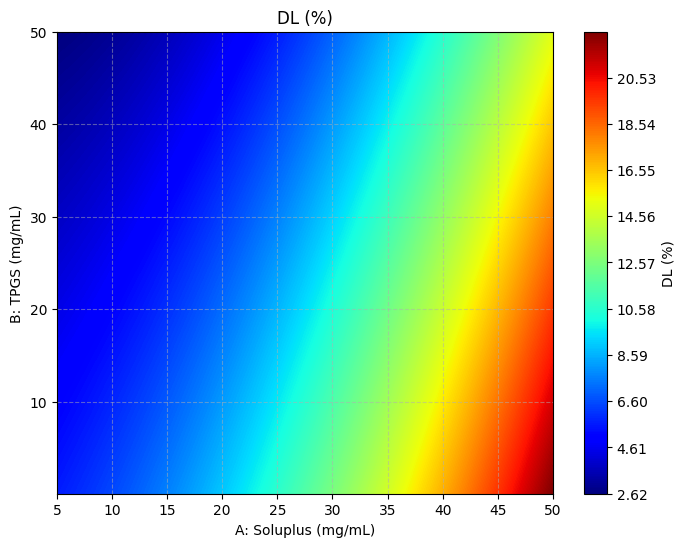

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Crear los datos (Simularemos una función de respuesta)
x = np.linspace(5, 50, 100)  # Eje A: Soluplus
y = np.linspace(0.05, 50, 100) # Eje B: TPGS
X, Y = np.meshgrid(x, y)

# Definimos una función que genere un mapa de calor similar a tu imagen
# (Z representa el DL %)
Z = 5 + 0.1*X - 0.05*Y + 0.005*X**2 - 0.002*X*Y

# 2. Configurar el gráfico
plt.figure(figsize=(8, 6))

# Dibujar el contorno relleno (el degradado de color)
# 'jet' o 'turbo' son mapas de colores similares al de tu imagen
cp = plt.contourf(X, Y, Z, levels=2000, cmap='jet')

# Añadir las líneas de contorno negras
#line_colors = ['black']
#contours = plt.contour(X, Y, Z, levels=8, colors=line_colors, linewidths=0.8)

# Añadir las etiquetas de los valores en las líneas (clabel)
plt.clabel(contours, inline=True, fontsize=10, fmt='%1.0f')

# 3. Estética y etiquetas
plt.colorbar(cp, label='DL (%)') # Barra de color lateral
plt.title('DL (%)')
plt.xlabel('A: Soluplus (mg/mL)')
plt.ylabel('B: TPGS (mg/mL)')

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()